In [2]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

PROJECT_ROOT = Path(r"C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis")
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd()

OUTPUT_DIR  = PROJECT_ROOT / "outputs"
MODELS_DIR  = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"
SRC_DIR     = PROJECT_ROOT / "src"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(SRC_DIR))

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "savefig.dpi": 300,
})
sns.set_style("whitegrid")
PALETTE = sns.color_palette("tab10")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR  :", OUTPUT_DIR)


PROJECT_ROOT: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis
OUTPUT_DIR  : /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/outputs


In [3]:
# Загрузка корпуса
df_corpus = pd.read_csv(OUTPUT_DIR / "clean_corpus.csv")
df_corpus["tokens"] = df_corpus["tokens"].apply(
    lambda x: x.split() if isinstance(x, str) else x
)
texts = df_corpus["tokens"].tolist()
docs  = df_corpus["tokens"].apply(" ".join).tolist()

print(f"Документов в корпусе: {len(df_corpus)}")


Документов в корпусе: 6385


---
## 1. BERTopic

In [ ]:
from bertopic import BERTopic
from umap import UMAP

print("Загрузка BERTopic модели...")
topic_model = BERTopic.load(str(MODELS_DIR / "bertopic_model"))

topic_info = topic_model.get_topic_info()
topic_info_valid = topic_info[topic_info["Topic"] != -1].copy()

df_bert = pd.read_csv(OUTPUT_DIR / "documents_with_topics.csv")
topics = df_bert["topic"].tolist()

n_topics = len(topic_info_valid)
n_outliers = list(topics).count(-1)
n_assigned = len(topics) - n_outliers

print(f"Тем: {n_topics}  |  Документов в темах: {n_assigned}  |  Шум: {n_outliers}")


Загрузка BERTopic модели...
Тем: 103  |  Документов в темах: 3632  |  Шум: 2753


### 1.1 Распределение документов по темам

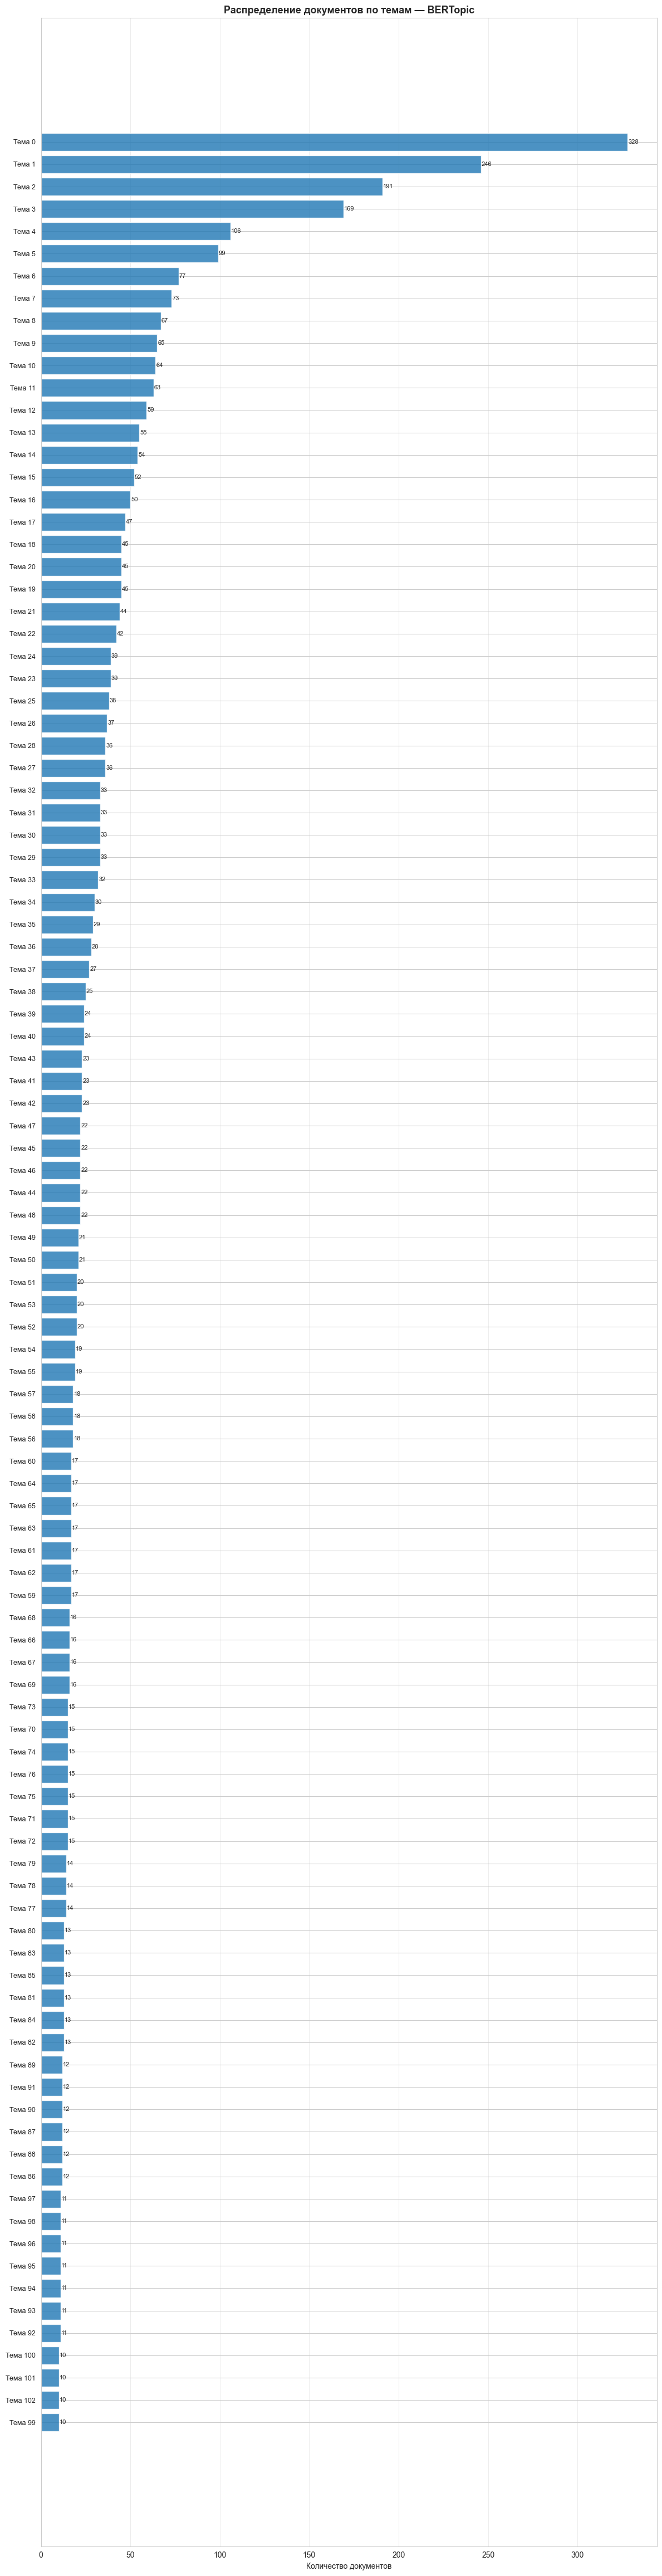

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\viz_bertopic_topic_distribution.png


In [ ]:
plot_df = topic_info_valid.sort_values("Count", ascending=True)
n_show = len(plot_df)

fig, ax = plt.subplots(figsize=(12, max(5, n_show * 0.45)))
bars = ax.barh(range(n_show), plot_df["Count"].values,
               color=PALETTE[0], alpha=0.80, edgecolor="white")
ax.set_yticks(range(n_show))
ax.set_yticklabels([f"Тема {t}" for t in plot_df["Topic"].values], fontsize=9)
ax.set_xlabel("Количество документов")
ax.set_title("Распределение документов по темам — BERTopic")
for bar, val in zip(bars, plot_df["Count"].values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=8)
ax.grid(axis="x", alpha=0.35)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "viz_bertopic_topic_distribution.png")
plt.show()
print("Сохранено:", FIGURES_DIR / "viz_bertopic_topic_distribution.png")


### 1.2 UMAP-проекция документов по темам

Вычисление эмбеддингов (inference, не обучение)...
Снижение размерности UMAP до 2D...


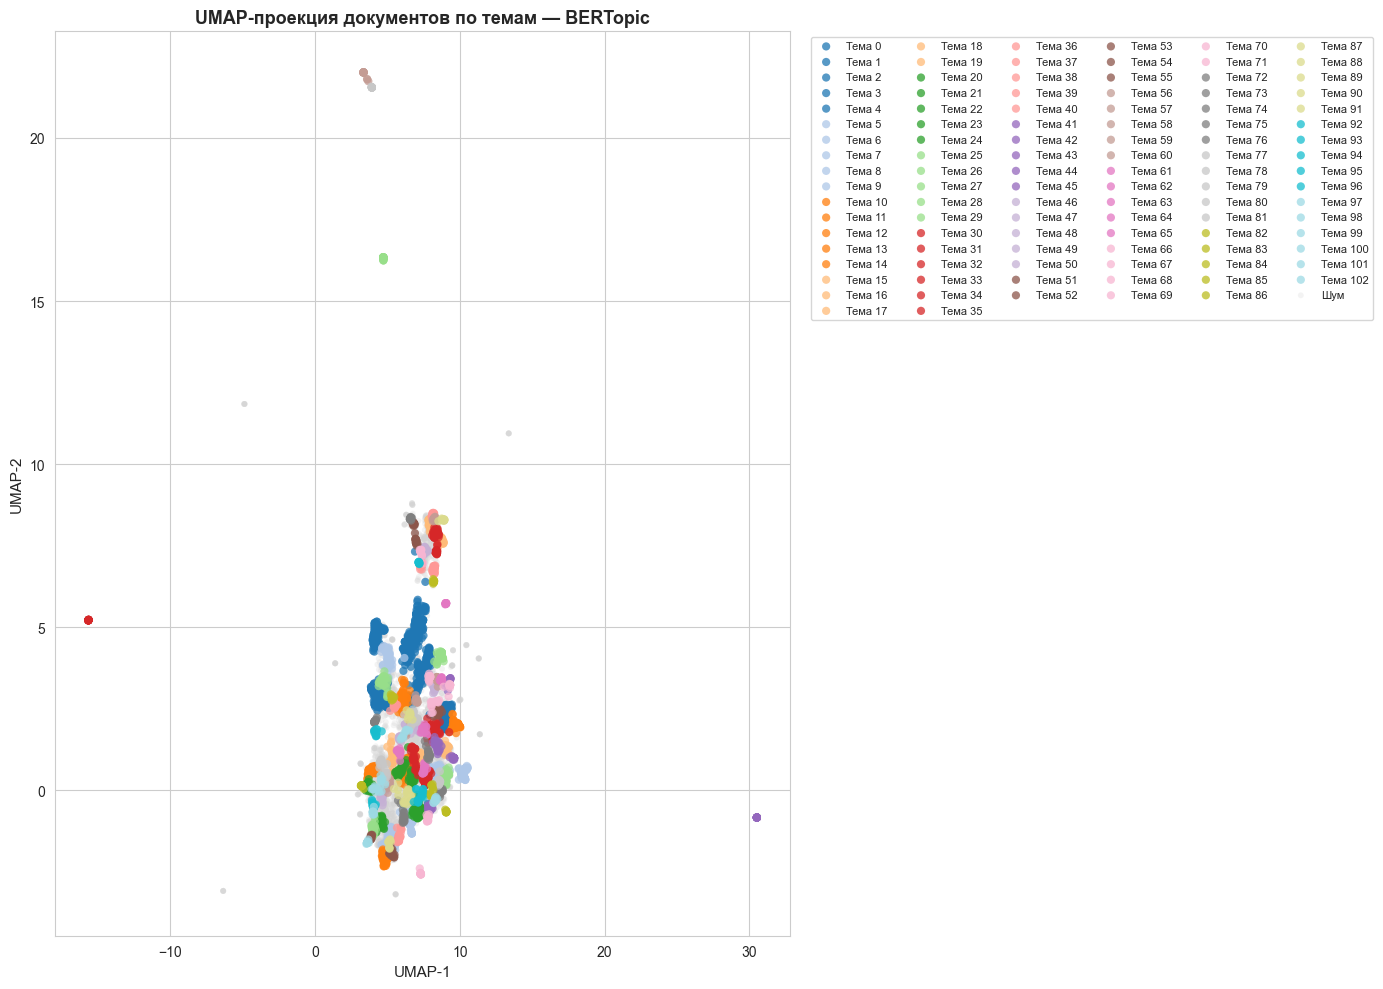

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\viz_bertopic_umap.png


In [ ]:
print("Вычисление эмбеддингов (inference, не обучение)...")
embeddings = topic_model._extract_embeddings(docs, method="document")

print("Снижение размерности UMAP до 2D...")
umap_2d = UMAP(n_neighbors=15, n_components=2,
               min_dist=0.05, metric="cosine", random_state=42)
reduced = umap_2d.fit_transform(embeddings)

unique_topics = sorted(set(topics))
cmap = cm.get_cmap("tab20", len(unique_topics))

fig, ax = plt.subplots(figsize=(14, 10))
for i, tid in enumerate(unique_topics):
    mask = np.array([t == tid for t in topics])
    if tid == -1:
        ax.scatter(reduced[mask, 0], reduced[mask, 1],
                   c="lightgray", label="Шум",
                   alpha=0.25, s=18, edgecolors="none", zorder=1)
    else:
        ax.scatter(reduced[mask, 0], reduced[mask, 1],
                   c=[cmap(i)], label=f"Тема {tid}",
                   alpha=0.75, s=35, edgecolors="none", zorder=2)

ax.set_xlabel("UMAP-1", fontsize=11)
ax.set_ylabel("UMAP-2", fontsize=11)
ax.set_title("UMAP-проекция документов по темам - BERTopic")

handles, labels_leg = ax.get_legend_handles_labels()
rest  = [(h, l) for h, l in zip(handles, labels_leg) if l != "Шум"]
noise = [(h, l) for h, l in zip(handles, labels_leg) if l == "Шум"]
if rest:
    h_s, l_s = zip(*(rest + noise))
else:
    h_s, l_s = handles, labels_leg

ax.legend(h_s, l_s,
          bbox_to_anchor=(1.02, 1), loc="upper left",
          fontsize=8, framealpha=0.8,
          ncol=1 + (n_topics // 20))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "viz_bertopic_umap.png")
plt.show()
print("Сохранено:", FIGURES_DIR / "viz_bertopic_umap.png")


### 1.3 Облака слов крупнейших тем

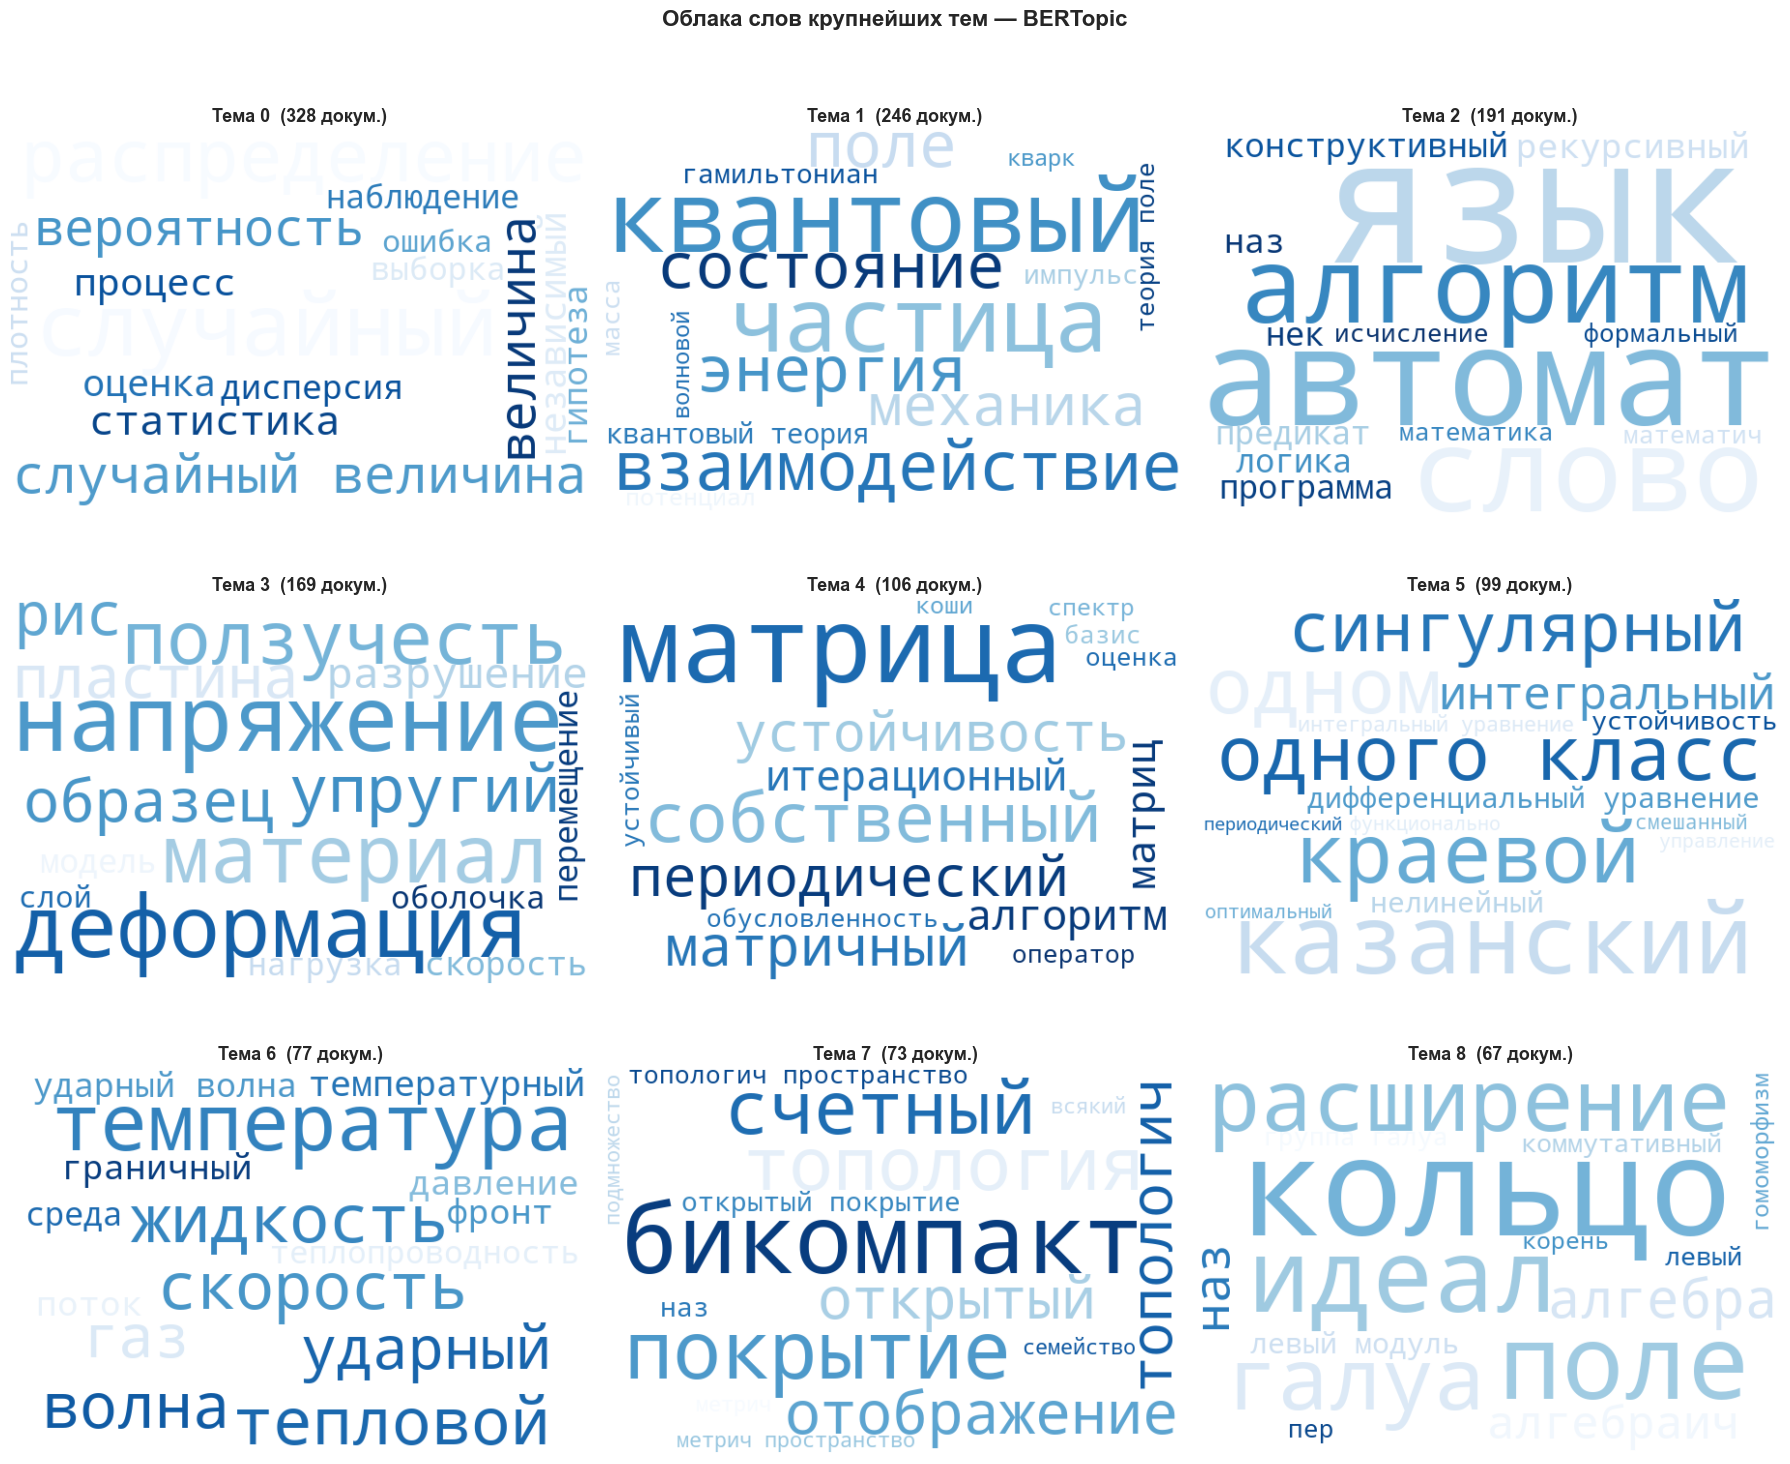

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\viz_bertopic_wordclouds.png


In [ ]:
try:
    from wordcloud import WordCloud
    _wc_available = True
except ImportError:
    print("нужен wordcloud")
    _wc_available = False

if _wc_available:
    TOP_N = min(9, n_topics)
    top_topic_ids = topic_info_valid.nlargest(TOP_N, "Count")["Topic"].values

    cols = 3
    rows = (TOP_N + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
    axes = axes.flatten()

    for i, tid in enumerate(top_topic_ids):
        words = topic_model.get_topic(tid)
        freq  = {w: max(s, 0) for w, s in words if max(s, 0) > 0}
        count = topic_info_valid.loc[
            topic_info_valid["Topic"] == tid, "Count"
        ].values[0]

        wc = WordCloud(
            width=600, height=400,
            background_color="white",
            colormap="Blues",
            max_words=30,
            prefer_horizontal=0.85,
        ).generate_from_frequencies(freq)

        axes[i].imshow(wc, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(f"Тема {tid}  ({count} докум.)", fontweight="bold")

    for j in range(TOP_N, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Облака слов крупнейших тем — BERTopic",
                 fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "viz_bertopic_wordclouds.png")
    plt.show()
    print("Сохранено:", FIGURES_DIR / "viz_bertopic_wordclouds.png")


### 1.4 Тепловая карта матрицы схожести тем

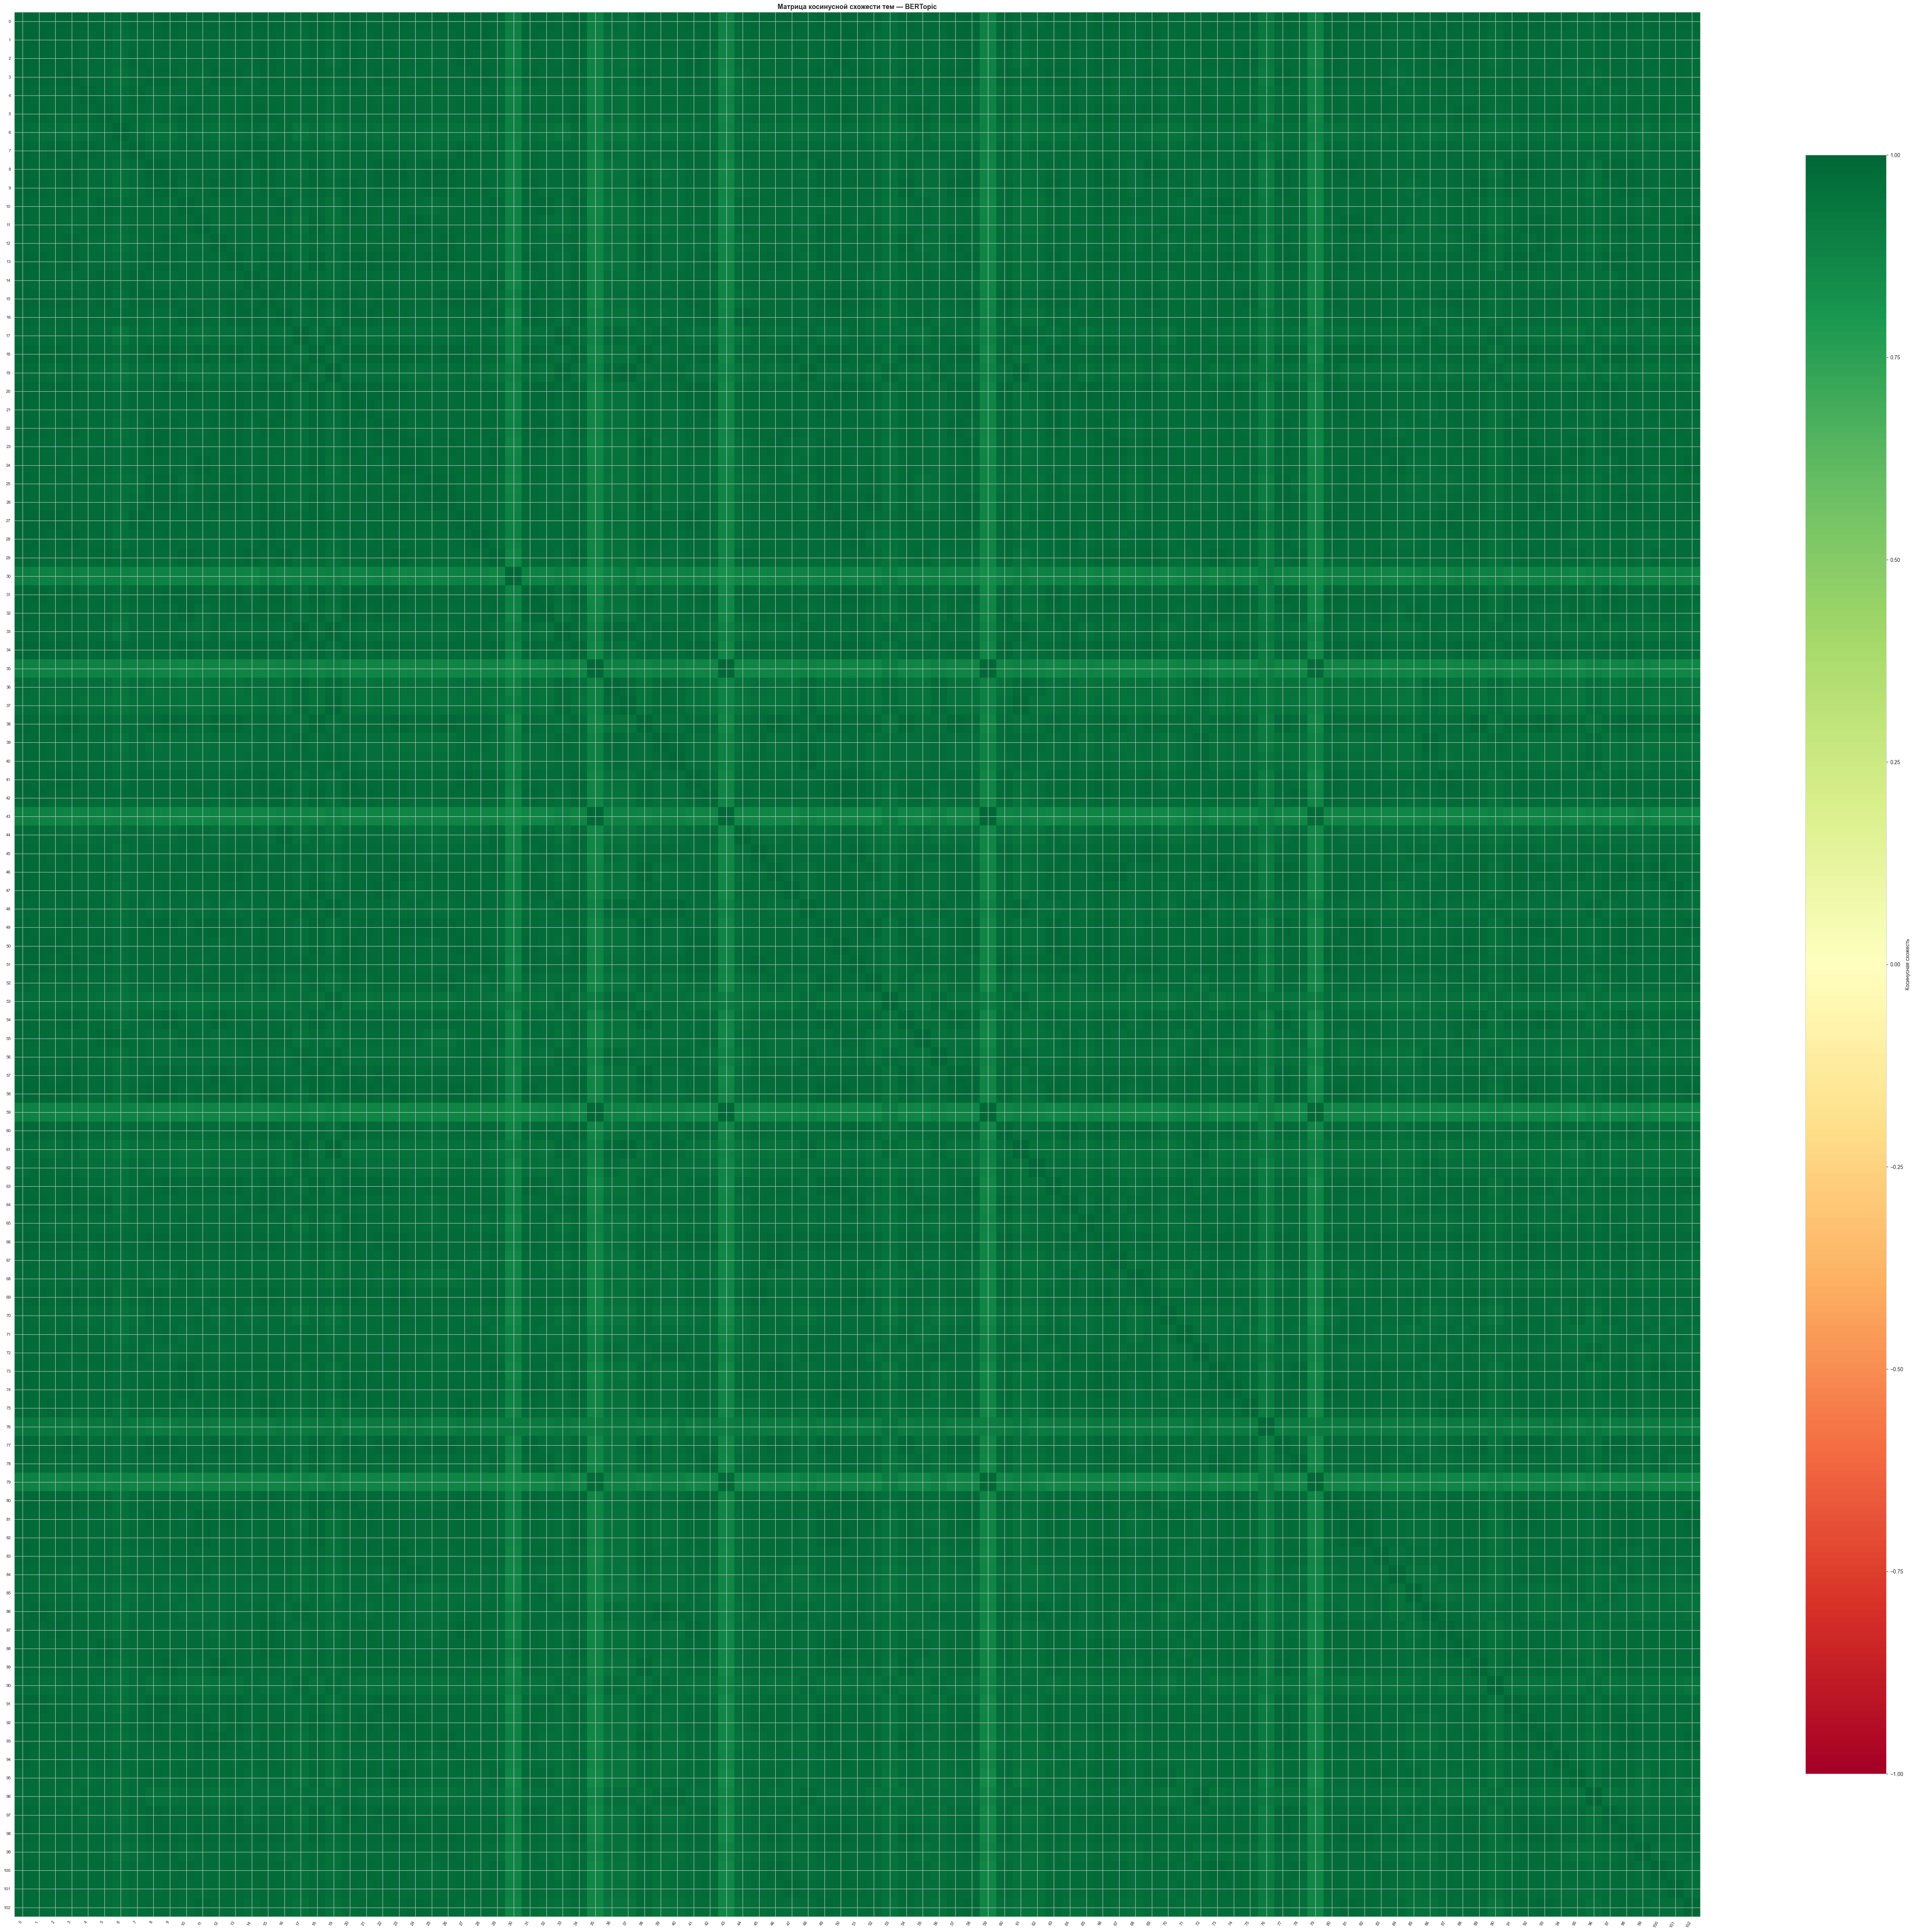

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\viz_bertopic_similarity.png


In [ ]:
emb = topic_model.topic_embeddings_
if emb is not None:
    t_ids = sorted(topic_info_valid["Topic"].values)
    subset = emb[t_ids]
    sim_mat = cosine_similarity(subset)

    fig, ax = plt.subplots(figsize=(max(8, len(t_ids) * 0.55),
                                    max(6, len(t_ids) * 0.50)))
    im = ax.imshow(sim_mat, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(t_ids)))
    ax.set_yticks(range(len(t_ids)))
    ax.set_xticklabels(t_ids, rotation=60, ha="right", fontsize=8)
    ax.set_yticklabels(t_ids, fontsize=8)
    ax.set_title("Матрица косинусной схожести тем — BERTopic")
    plt.colorbar(im, ax=ax, label="Косинусная схожесть", shrink=0.85)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "viz_bertopic_similarity.png")
    plt.show()
    print("Сохранено:", FIGURES_DIR / "viz_bertopic_similarity.png")
else:
    print("topic_embeddings_ недоступны.")


---
## 2. BigARTM

In [ ]:
# Попытка загрузить artm (только в окружении venv_bigartm)
try:
    import artm as _artm_lib
    BIGARTM_AVAILABLE = True
    print("BigARTM:", _artm_lib.version())
except ImportError:
    BIGARTM_AVAILABLE = False
    print("artm не найден, нужно соответсвующее окружение")

# Загрузка из CSV 
df_bigartm = pd.read_csv(OUTPUT_DIR / "bigartm_documents_topics.csv")
topic_weight_cols = [c for c in df_bigartm.columns
                       if c.startswith("topic_") and c.endswith("_weight")]
NUM_TOPICS_BIGARTM  = len(topic_weight_cols)
print(f"Документов: {len(df_bigartm)}  |  Тем: {NUM_TOPICS_BIGARTM}")


BigARTM: 0.9.2
Документов: 6385  |  Тем: 30


### 2.1 Кривые обучения BigARTM

In [ ]:
curves_path = OUTPUT_DIR / "bigartm_training_curves.csv"

if curves_path.exists():
    curves = pd.read_csv(curves_path)
    iters = curves["iteration"].values

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Перплексия
    ax = axes[0]
    ax.plot(iters, curves["perplexity"], color="coral", linewidth=2.5)
    ax.fill_between(iters, curves["perplexity"], alpha=0.12, color="coral")
    ax.set_xlabel("Итерация")
    ax.set_ylabel("Перплексия")
    ax.set_title("Сходимость: перплексия")
    ax.grid(True, alpha=0.35)

    # Разреженность
    ax = axes[1]
    ax.plot(iters, curves["sparsity_phi"],   color="steelblue", linewidth=2.5,
            label="Φ (слова × темы)")
    ax.plot(iters, curves["sparsity_theta"], color="seagreen",  linewidth=2.5,
            linestyle="--", label="Θ (темы × документы)")
    ax.set_xlabel("Итерация")
    ax.set_ylabel("Доля нулей")
    ax.set_title("Разреженность матриц")
    ax.legend()
    ax.grid(True, alpha=0.35)

    # Совмещённый
    ax = axes[2]
    ax2 = ax.twinx()
    ax.plot(iters, curves["perplexity"],     color="coral",     linewidth=2,
            label="Перплексия (лев. ось)")
    ax2.plot(iters, curves["sparsity_phi"],  color="steelblue", linewidth=2,
             linestyle="--", label="Sparse Φ (пр. ось)")
    ax2.plot(iters, curves["sparsity_theta"], color="seagreen", linewidth=2,
             linestyle=":",  label="Sparse Θ (пр. ось)")
    ax.set_xlabel("Итерация")
    ax.set_ylabel("Перплексия", color="coral")
    ax2.set_ylabel("Доля нулей")
    ax.tick_params(axis="y", labelcolor="coral")
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper right")
    ax.set_title("Перплексия + разреженность")
    ax.grid(True, alpha=0.35)

    plt.suptitle("Динамика обучения финальной BigARTM модели",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "viz_bigartm_training_curves.png")
    plt.show()
    print("Сохранено:", FIGURES_DIR / "viz_bigartm_training_curves.png")
else:
    print("Файл bigartm_training_curves.csv не найден.")


NameError: name 'OUTPUT_DIR' is not defined

### 2.2 Распределение документов по темам

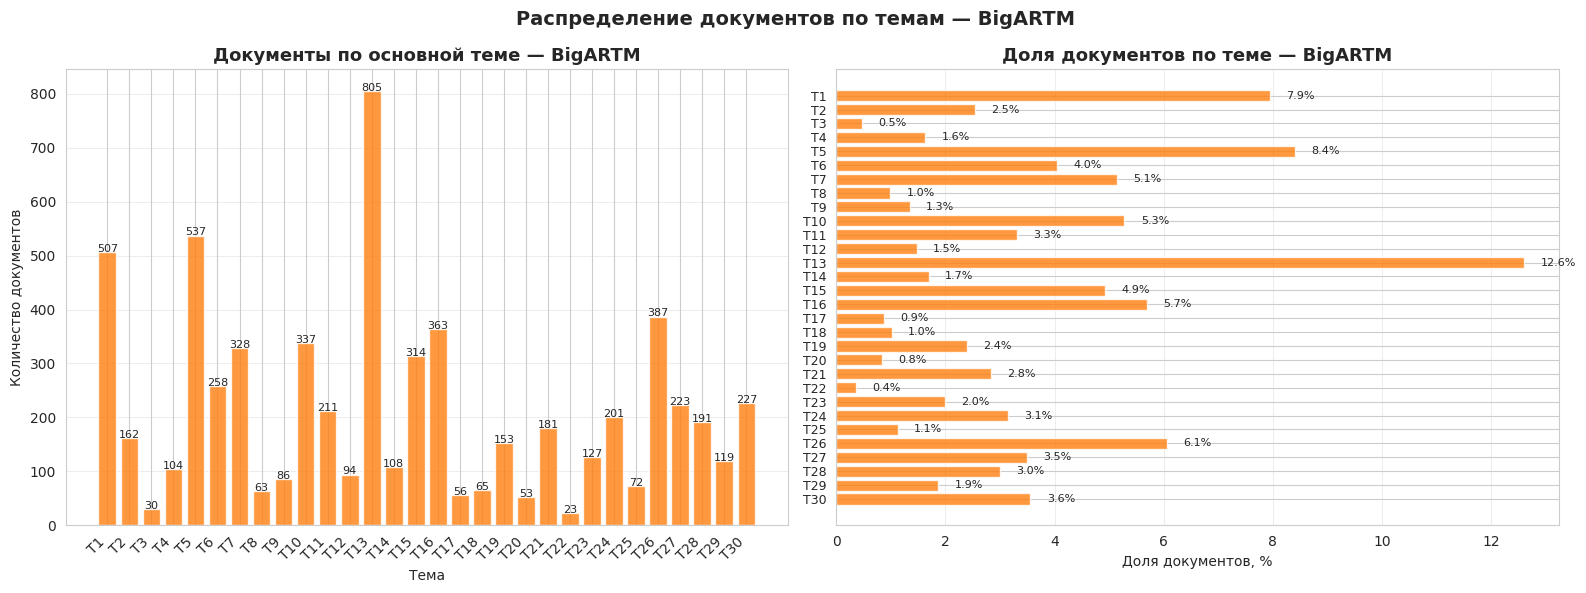

Сохранено: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/figures/viz_bigartm_topic_distribution.png


In [ ]:
topic_counts = df_bigartm["dominant_topic"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Гистограмма
ax = axes[0]
x    = range(len(topic_counts))
bars = ax.bar(x, topic_counts.values,
              color=PALETTE[1], alpha=0.80, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([f"Т{i+1}" for i in range(len(topic_counts))],
                   rotation=45, ha="right")
ax.set_xlabel("Тема")
ax.set_ylabel("Количество документов")
ax.set_title("Документы по основной теме — BigARTM")
for bar, val in zip(bars, topic_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(val), ha="center", fontsize=8)
ax.grid(axis="y", alpha=0.35)

# Доля
ax = axes[1]
shares = topic_counts.values / topic_counts.sum() * 100
ax.barh(range(len(topic_counts)), shares,
        color=PALETTE[1], alpha=0.80, edgecolor="white")
ax.set_yticks(range(len(topic_counts)))
ax.set_yticklabels([f"Т{i+1}" for i in range(len(topic_counts))], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Доля документов, %")
ax.set_title("Доля документов по теме — BigARTM")
for i, v in enumerate(shares):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)
ax.grid(axis="x", alpha=0.35)

plt.suptitle("Распределение документов по темам — BigARTM",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "viz_bigartm_topic_distribution.png")
plt.show()
print("Сохранено:", FIGURES_DIR / "viz_bigartm_topic_distribution.png")


### 2.3 Тепловая карта матрицы Θ

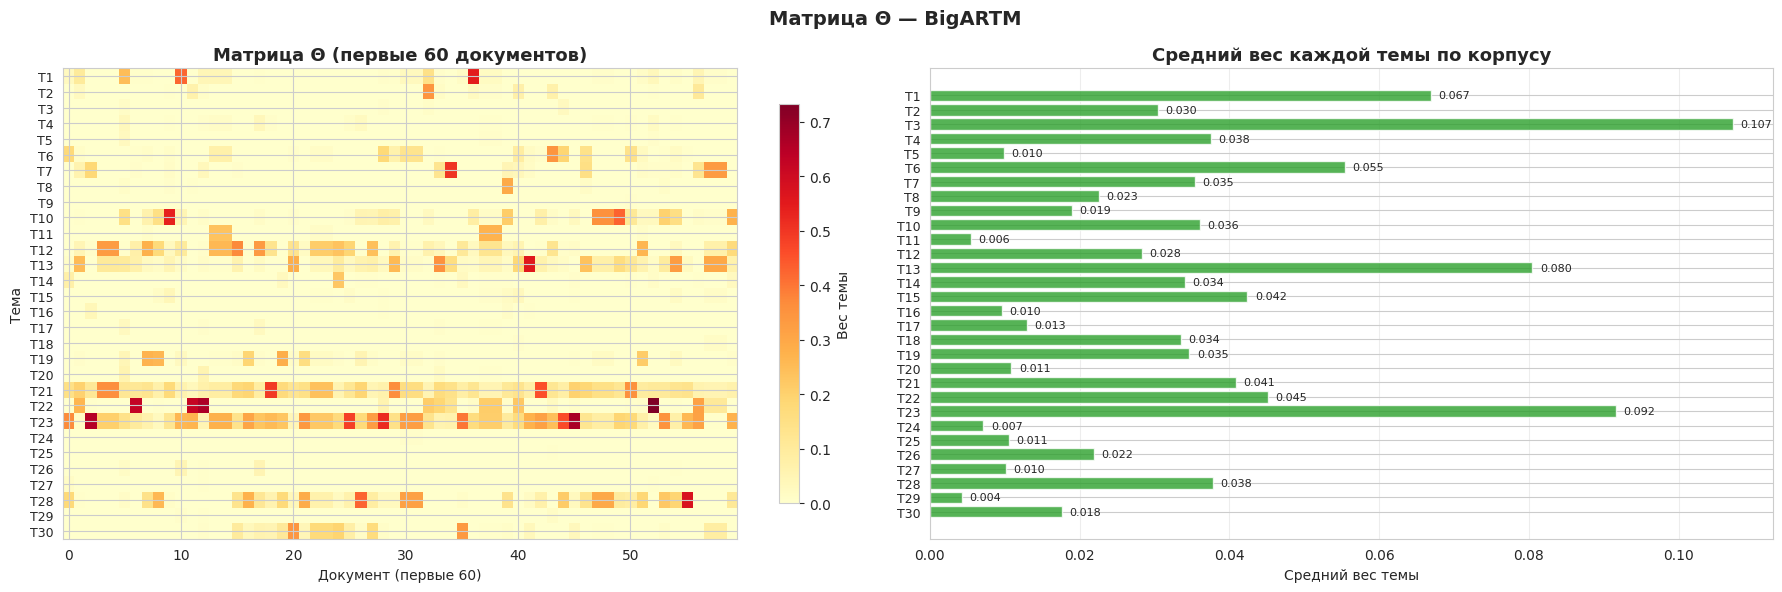

Сохранено: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/figures/viz_bigartm_theta.png


In [ ]:
# Θ восстанавливается напрямую из CSV — artm не нужен
theta_df = df_bigartm[topic_weight_cols].T   # темы × документы
theta_np = theta_df.values

show_docs = min(60, theta_np.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Тепловая карта
ax = axes[0]
im = ax.imshow(theta_np[:, :show_docs], cmap="YlOrRd",
               aspect="auto", vmin=0)
ax.set_xlabel(f"Документ (первые {show_docs})")
ax.set_ylabel("Тема")
ax.set_yticks(range(NUM_TOPICS_BIGARTM))
ax.set_yticklabels([f"Т{i+1}" for i in range(NUM_TOPICS_BIGARTM)], fontsize=9)
ax.set_title(f"Матрица Θ (первые {show_docs} документов)")
plt.colorbar(im, ax=ax, label="Вес темы", shrink=0.85)

# Средний вес каждой темы
ax = axes[1]
mean_weights = theta_df.mean(axis=1).values
ax.barh(range(NUM_TOPICS_BIGARTM), mean_weights,
        color=PALETTE[2], alpha=0.80, edgecolor="white")
ax.set_yticks(range(NUM_TOPICS_BIGARTM))
ax.set_yticklabels([f"Т{i+1}" for i in range(NUM_TOPICS_BIGARTM)], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Средний вес темы")
ax.set_title("Средний вес каждой темы по корпусу")
for i, v in enumerate(mean_weights):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8)
ax.grid(axis="x", alpha=0.35)

plt.suptitle("Матрица Θ — BigARTM", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "viz_bigartm_theta.png")
plt.show()
print("Сохранено:", FIGURES_DIR / "viz_bigartm_theta.png")


### 2.4 Матрица схожести тем (по Φ) и облака слов

> Следующие две ячейки требуют `artm` — запускайте в окружении `venv_bigartm`.


Загрузка BigARTM модели для get_phi()...


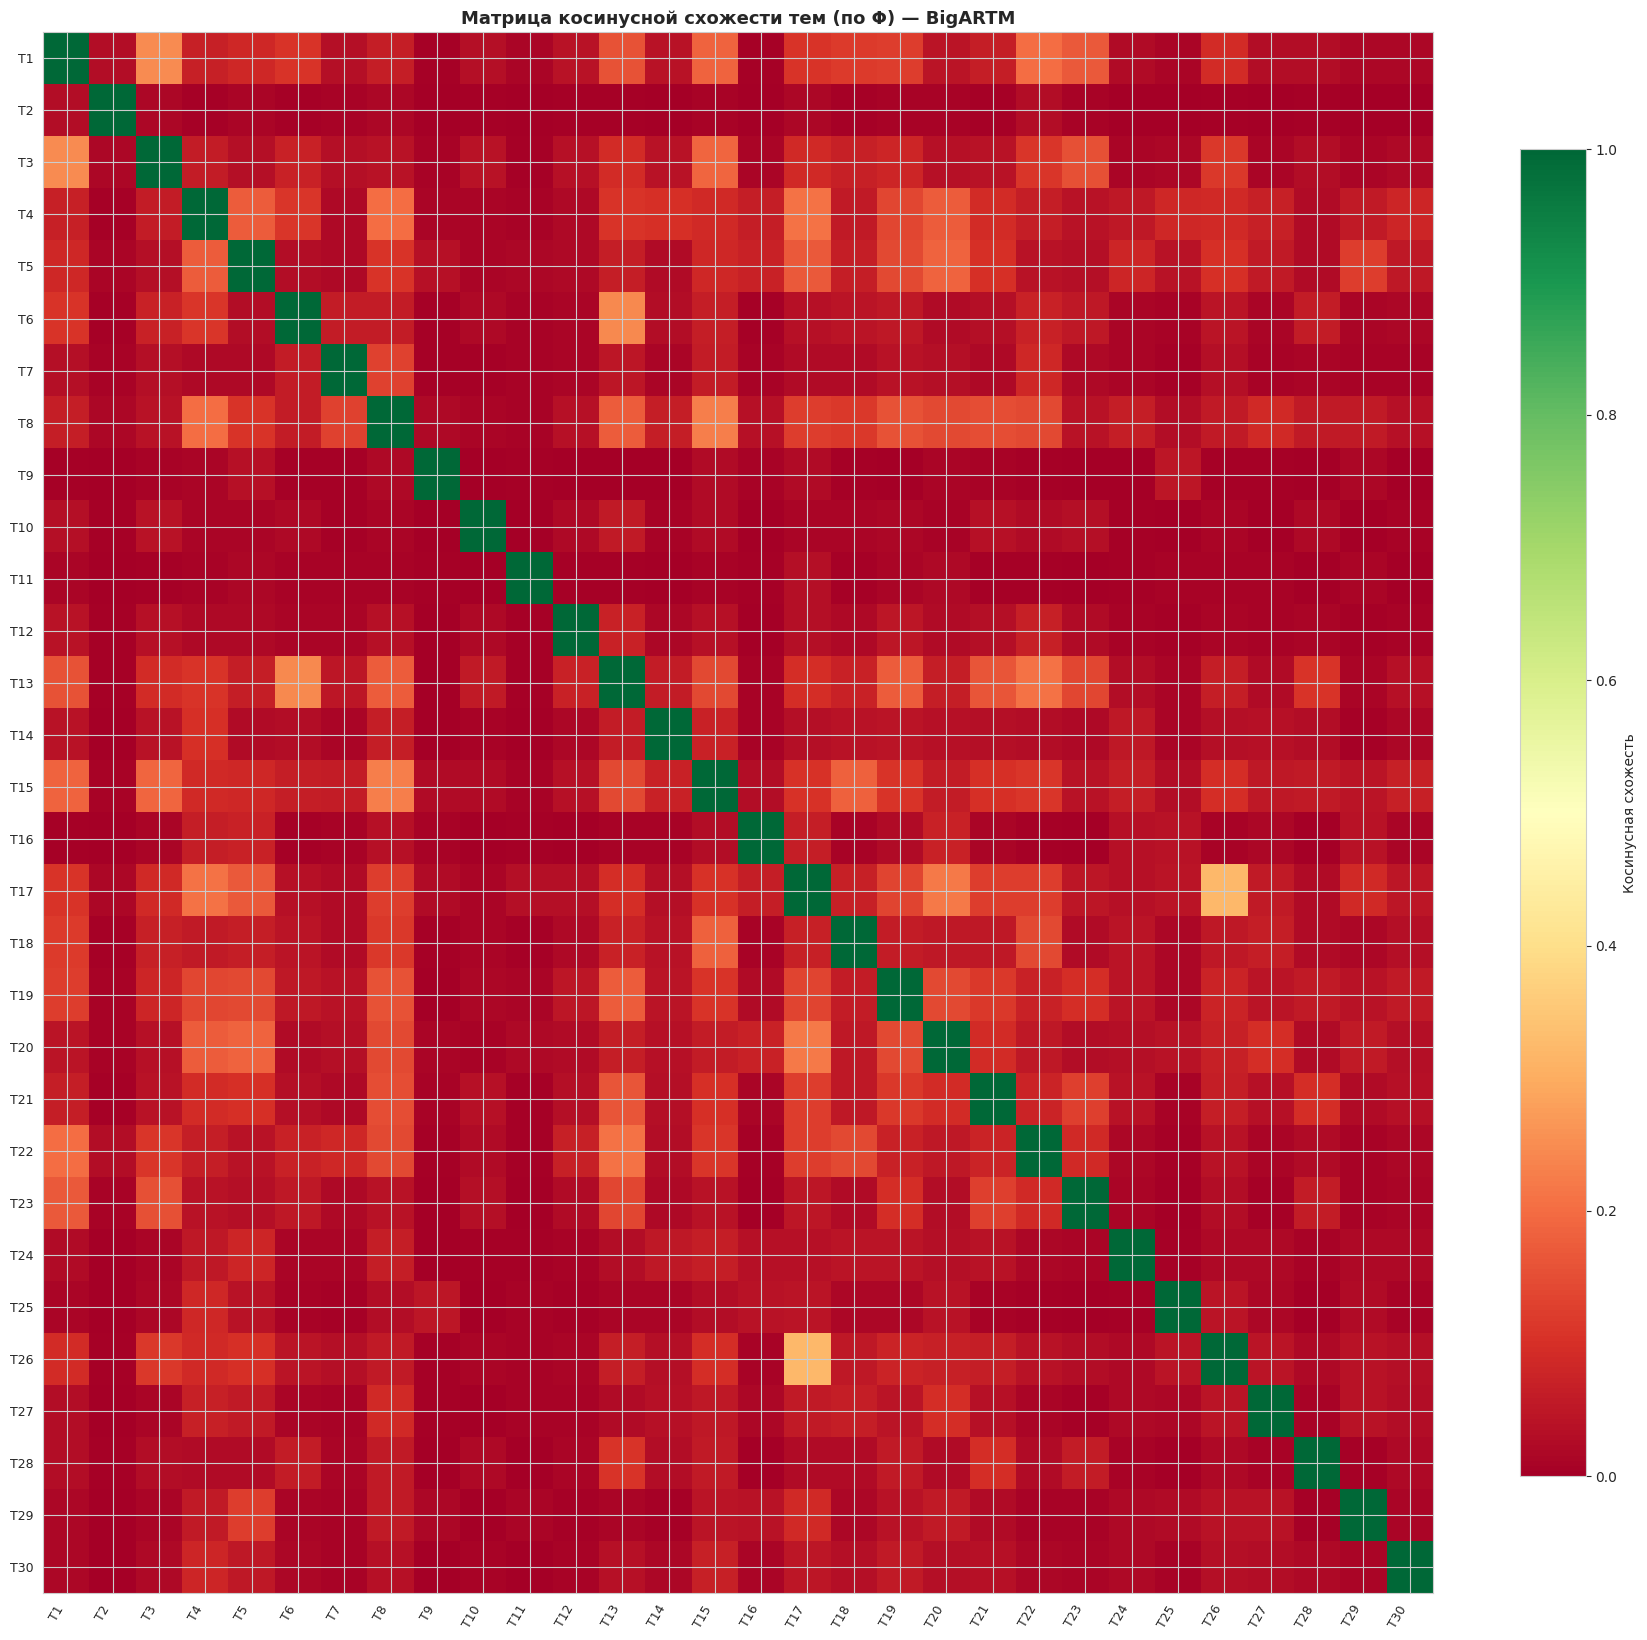

Сохранено: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/figures/viz_bigartm_similarity.png


In [ ]:
if BIGARTM_AVAILABLE:
    import artm

    print("Загрузка BigARTM модели для get_phi()...")
    bigartm_model = artm.ARTM(num_topics=NUM_TOPICS_BIGARTM)
    bigartm_model.load(str(MODELS_DIR / "bigartm_model_best"))

    phi = bigartm_model.get_phi()   # DataFrame: слова × темы
    phi_T = phi.values.T # темы × слова
    sim_matrix = cosine_similarity(phi_T)

    topic_labels_short = [f"Т{i+1}" for i in range(NUM_TOPICS_BIGARTM)]

    fig, ax = plt.subplots(figsize=(max(8, NUM_TOPICS_BIGARTM * 0.6),
                                    max(6, NUM_TOPICS_BIGARTM * 0.55)))
    im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(NUM_TOPICS_BIGARTM))
    ax.set_yticks(range(NUM_TOPICS_BIGARTM))
    ax.set_xticklabels(topic_labels_short, rotation=60, ha="right", fontsize=9)
    ax.set_yticklabels(topic_labels_short, fontsize=9)
    ax.set_title("Матрица косинусной схожести тем (по Φ) — BigARTM")
    plt.colorbar(im, ax=ax, label="Косинусная схожесть", shrink=0.85)

    if NUM_TOPICS_BIGARTM <= 20:
        for i in range(NUM_TOPICS_BIGARTM):
            for j in range(NUM_TOPICS_BIGARTM):
                color = "white" if sim_matrix[i, j] > 0.7 else "black"
                ax.text(j, i, f"{sim_matrix[i, j]:.2f}",
                        ha="center", va="center", fontsize=7, color=color)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "viz_bigartm_similarity.png")
    plt.show()
    print("Сохранено:", FIGURES_DIR / "viz_bigartm_similarity.png")
else:
    print("artm недоступен")


In [9]:
if BIGARTM_AVAILABLE and _wc_available:
    # Топ-слова по матрице Φ
    top_words_per_topic = {}
    for col in phi.columns:
        series = phi[col].sort_values(ascending=False)
        top_words_per_topic[col] = {w: float(v)
                                    for w, v in series.head(30).items()}

    TOP_N_WC = min(9, NUM_TOPICS_BIGARTM)
    cols_wc  = 3
    rows_wc  = (TOP_N_WC + cols_wc - 1) // cols_wc

    top_topic_names = topic_counts.index[:TOP_N_WC].tolist()

    fig, axes = plt.subplots(rows_wc, cols_wc, figsize=(18, rows_wc * 5))
    axes = axes.flatten()

    for i, topic_name in enumerate(top_topic_names):
        freq = top_words_per_topic.get(topic_name, {})
        cnt  = topic_counts.get(topic_name, 0)
        wc   = WordCloud(
            width=600, height=400,
            background_color="white",
            colormap="Oranges",
            max_words=30,
            prefer_horizontal=0.85,
        ).generate_from_frequencies(freq)
        axes[i].imshow(wc, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(f"{topic_name}  ({cnt} докум.)", fontweight="bold")

    for j in range(TOP_N_WC, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Облака слов крупнейших тем — BigARTM",
                 fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "viz_bigartm_wordclouds.png")
    plt.show()
    print("Сохранено:", FIGURES_DIR / "viz_bigartm_wordclouds.png")
elif not BIGARTM_AVAILABLE:
    print("[!] artm недоступен — пропускаем облака слов BigARTM.")
elif not _wc_available:
    print("[!] wordcloud не установлен: pip install wordcloud")


NameError: name '_wc_available' is not defined

---
## 3. Сводка сохранённых файлов

In [ ]:
saved = sorted(FIGURES_DIR.glob("viz_*.png"))
print(f"Создано файлов: {len(saved)}")
for p in saved:
    size_kb = p.stat().st_size // 1024
    print(f"  {p.name:<55} {size_kb:>5} KB")


Создано файлов: 6
  viz_bertopic_similarity.png                              1571 KB
  viz_bertopic_topic_distribution.png                       749 KB
  viz_bertopic_umap.png                                     488 KB
  viz_bertopic_wordclouds.png                              3619 KB
  viz_bigartm_theta.png                                     306 KB
  viz_bigartm_topic_distribution.png                        336 KB
